# 번호별 통계 분석

In [97]:
import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", rc={
    "font.family": "Apple SD Gothic Neo",
    "axes.unicode_minus": False
})

In [98]:
import matplotlib.font_manager as fm
print([f.name for f in fm.fontManager.ttflist if 'Gothic' in f.name])

['Toppan Bunkyu Gothic', 'Nanum Gothic', 'Tsukushi B Round Gothic', 'Apple SD Gothic Neo', 'Toppan Bunkyu Midashi Gothic', 'BIZ UDGothic', 'YuGothic', 'Apple LiGothic', 'YuGothic', 'Hiragino Maru Gothic Pro', 'Noto Sans Gothic', 'Tsukushi A Round Gothic', 'AppleGothic']


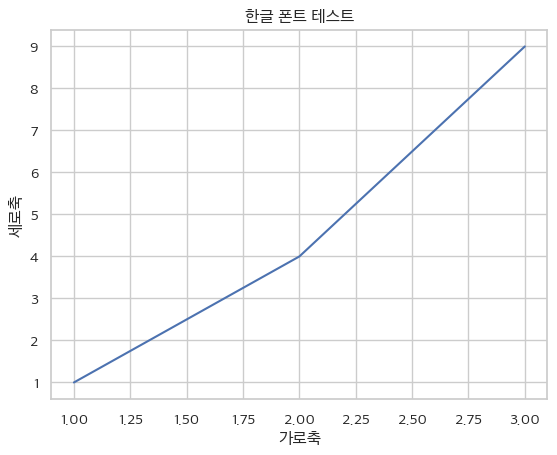

In [99]:
import matplotlib.pyplot as plt

# 전역 폰트 설정
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# 테스트
plt.plot([1, 2, 3], [1, 4, 9])
plt.title("한글 폰트 테스트")
plt.xlabel("가로축")
plt.ylabel("세로축")
plt.show()

In [100]:
original_df = pd.read_excel('./data/lotto_df.xlsx')
lotto_df = original_df
lotto_df.head()

,Unnamed: 0,년도,회차,추첨일,1등_당첨자수,1등_당첨금액,2등_당첨자수,2등_당첨금액,3등_당첨자수,3등_당첨금액,...,4등_당첨금액,5등_당첨자수,5등_당첨금액,당첨번호_1,당첨번호_2,당첨번호_3,당첨번호_4,당첨번호_5,당첨번호_6,보너스번호
0,0,2025,1184,20250809,15,1910655600,95,50280411,3115,1533432,...,50000,2576710,5000,14,16,23,25,31,37,42
1,1,2025,1183,20250802,13,2073966000,92,48843403,3623,1240297,...,50000,2680548,5000,4,15,17,23,27,36,31
2,2,2025,1182,20250726,13,2124785424,79,58274706,3015,1526933,...,50000,2616958,5000,1,13,21,25,28,31,22
3,3,2025,1181,20250719,17,1593643500,86,52503759,3109,1452340,...,50000,2596371,5000,8,10,14,20,33,41,28
4,4,2025,1180,20250712,11,2535566421,72,64563034,3010,1544365,...,50000,2567395,5000,6,12,18,37,40,41,3


### 전처리

In [101]:
lotto_df = lotto_df.drop(columns=[
    'Unnamed: 0', '년도', '회차', '추첨일',
    '1등_당첨자수', '1등_당첨금액',
    '2등_당첨자수', '2등_당첨금액', 
    '3등_당첨자수', '3등_당첨금액', 
    '4등_당첨자수', '4등_당첨금액', 
    '5등_당첨자수', '5등_당첨금액', 
], axis=1).reset_index(drop=True)

lotto_df

,당첨번호_1,당첨번호_2,당첨번호_3,당첨번호_4,당첨번호_5,당첨번호_6,보너스번호
0,14,16,23,25,31,37,42
1,4,15,17,23,27,36,31
2,1,13,21,25,28,31,22
3,8,10,14,20,33,41,28
4,6,12,18,37,40,41,3
...,...,...,...,...,...,...,...
1179,16,24,29,40,41,42,3
1180,14,27,30,31,40,42,2
1181,11,16,19,21,27,31,30
1182,9,13,21,25,32,42,2


### 숫자 출현 빈도

In [102]:
for i in range(1, 6):
    globals()[f'number_{i}_count'] = [0] * 45
    for num in lotto_df[f'당첨번호_{i}']:
        globals()[f'number_{i}_count'][num - 1] += 1

number_bonus_count = [0] * 45

for num in lotto_df['보너스번호']:
    number_bonus_count[num - 1] += 1
    
print('1번 당첨번호별 출현 빈도: ', number_1_count)
print('2번 당첨번호별 출현 빈도: ', number_2_count)
print('3번 당첨번호별 출현 빈도: ', number_3_count)
print('4번 당첨번호별 출현 빈도: ', number_4_count)
print('5번 당첨번호별 출현 빈도: ', number_5_count)
print('보너스 당첨번호별 출현 빈도: ', number_bonus_count)

1번 당첨번호별 출현 빈도:  [161, 127, 125, 103, 93, 93, 77, 59, 40, 47, 39, 40, 33, 35, 15, 23, 20, 7, 12, 6, 10, 5, 3, 2, 1, 3, 1, 0, 1, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
2번 당첨번호별 출현 빈도:  [0, 22, 36, 47, 49, 49, 76, 69, 61, 73, 70, 71, 56, 58, 56, 48, 46, 53, 33, 34, 32, 21, 25, 16, 18, 14, 16, 4, 5, 7, 6, 3, 4, 3, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0]
3번 당첨번호별 출현 빈도:  [0, 0, 3, 5, 5, 14, 11, 19, 22, 34, 38, 46, 64, 49, 57, 49, 56, 65, 65, 64, 47, 49, 40, 49, 40, 41, 39, 40, 34, 34, 27, 14, 16, 14, 12, 7, 9, 3, 2, 1, 0, 0, 0, 0, 0]
4번 당첨번호별 출현 빈도:  [0, 0, 0, 0, 1, 3, 0, 4, 4, 1, 15, 13, 16, 26, 28, 34, 33, 34, 35, 39, 50, 39, 50, 56, 54, 59, 59, 42, 47, 58, 60, 51, 56, 44, 42, 33, 27, 25, 15, 15, 10, 4, 2, 0, 0]
5번 당첨번호별 출현 빈도:  [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 3, 2, 1, 3, 5, 9, 11, 13, 17, 21, 20, 19, 31, 28, 34, 45, 48, 49, 37, 48, 49, 66, 82, 57, 62, 71, 69, 75, 60, 54, 49, 32, 12, 0]
보너스 당첨번호별 출현 빈도:  [32, 32, 31, 35, 25, 34, 30, 24, 24, 27, 24, 27, 27, 21, 25, 28, 32, 19, 22, 29,

##### 시각화

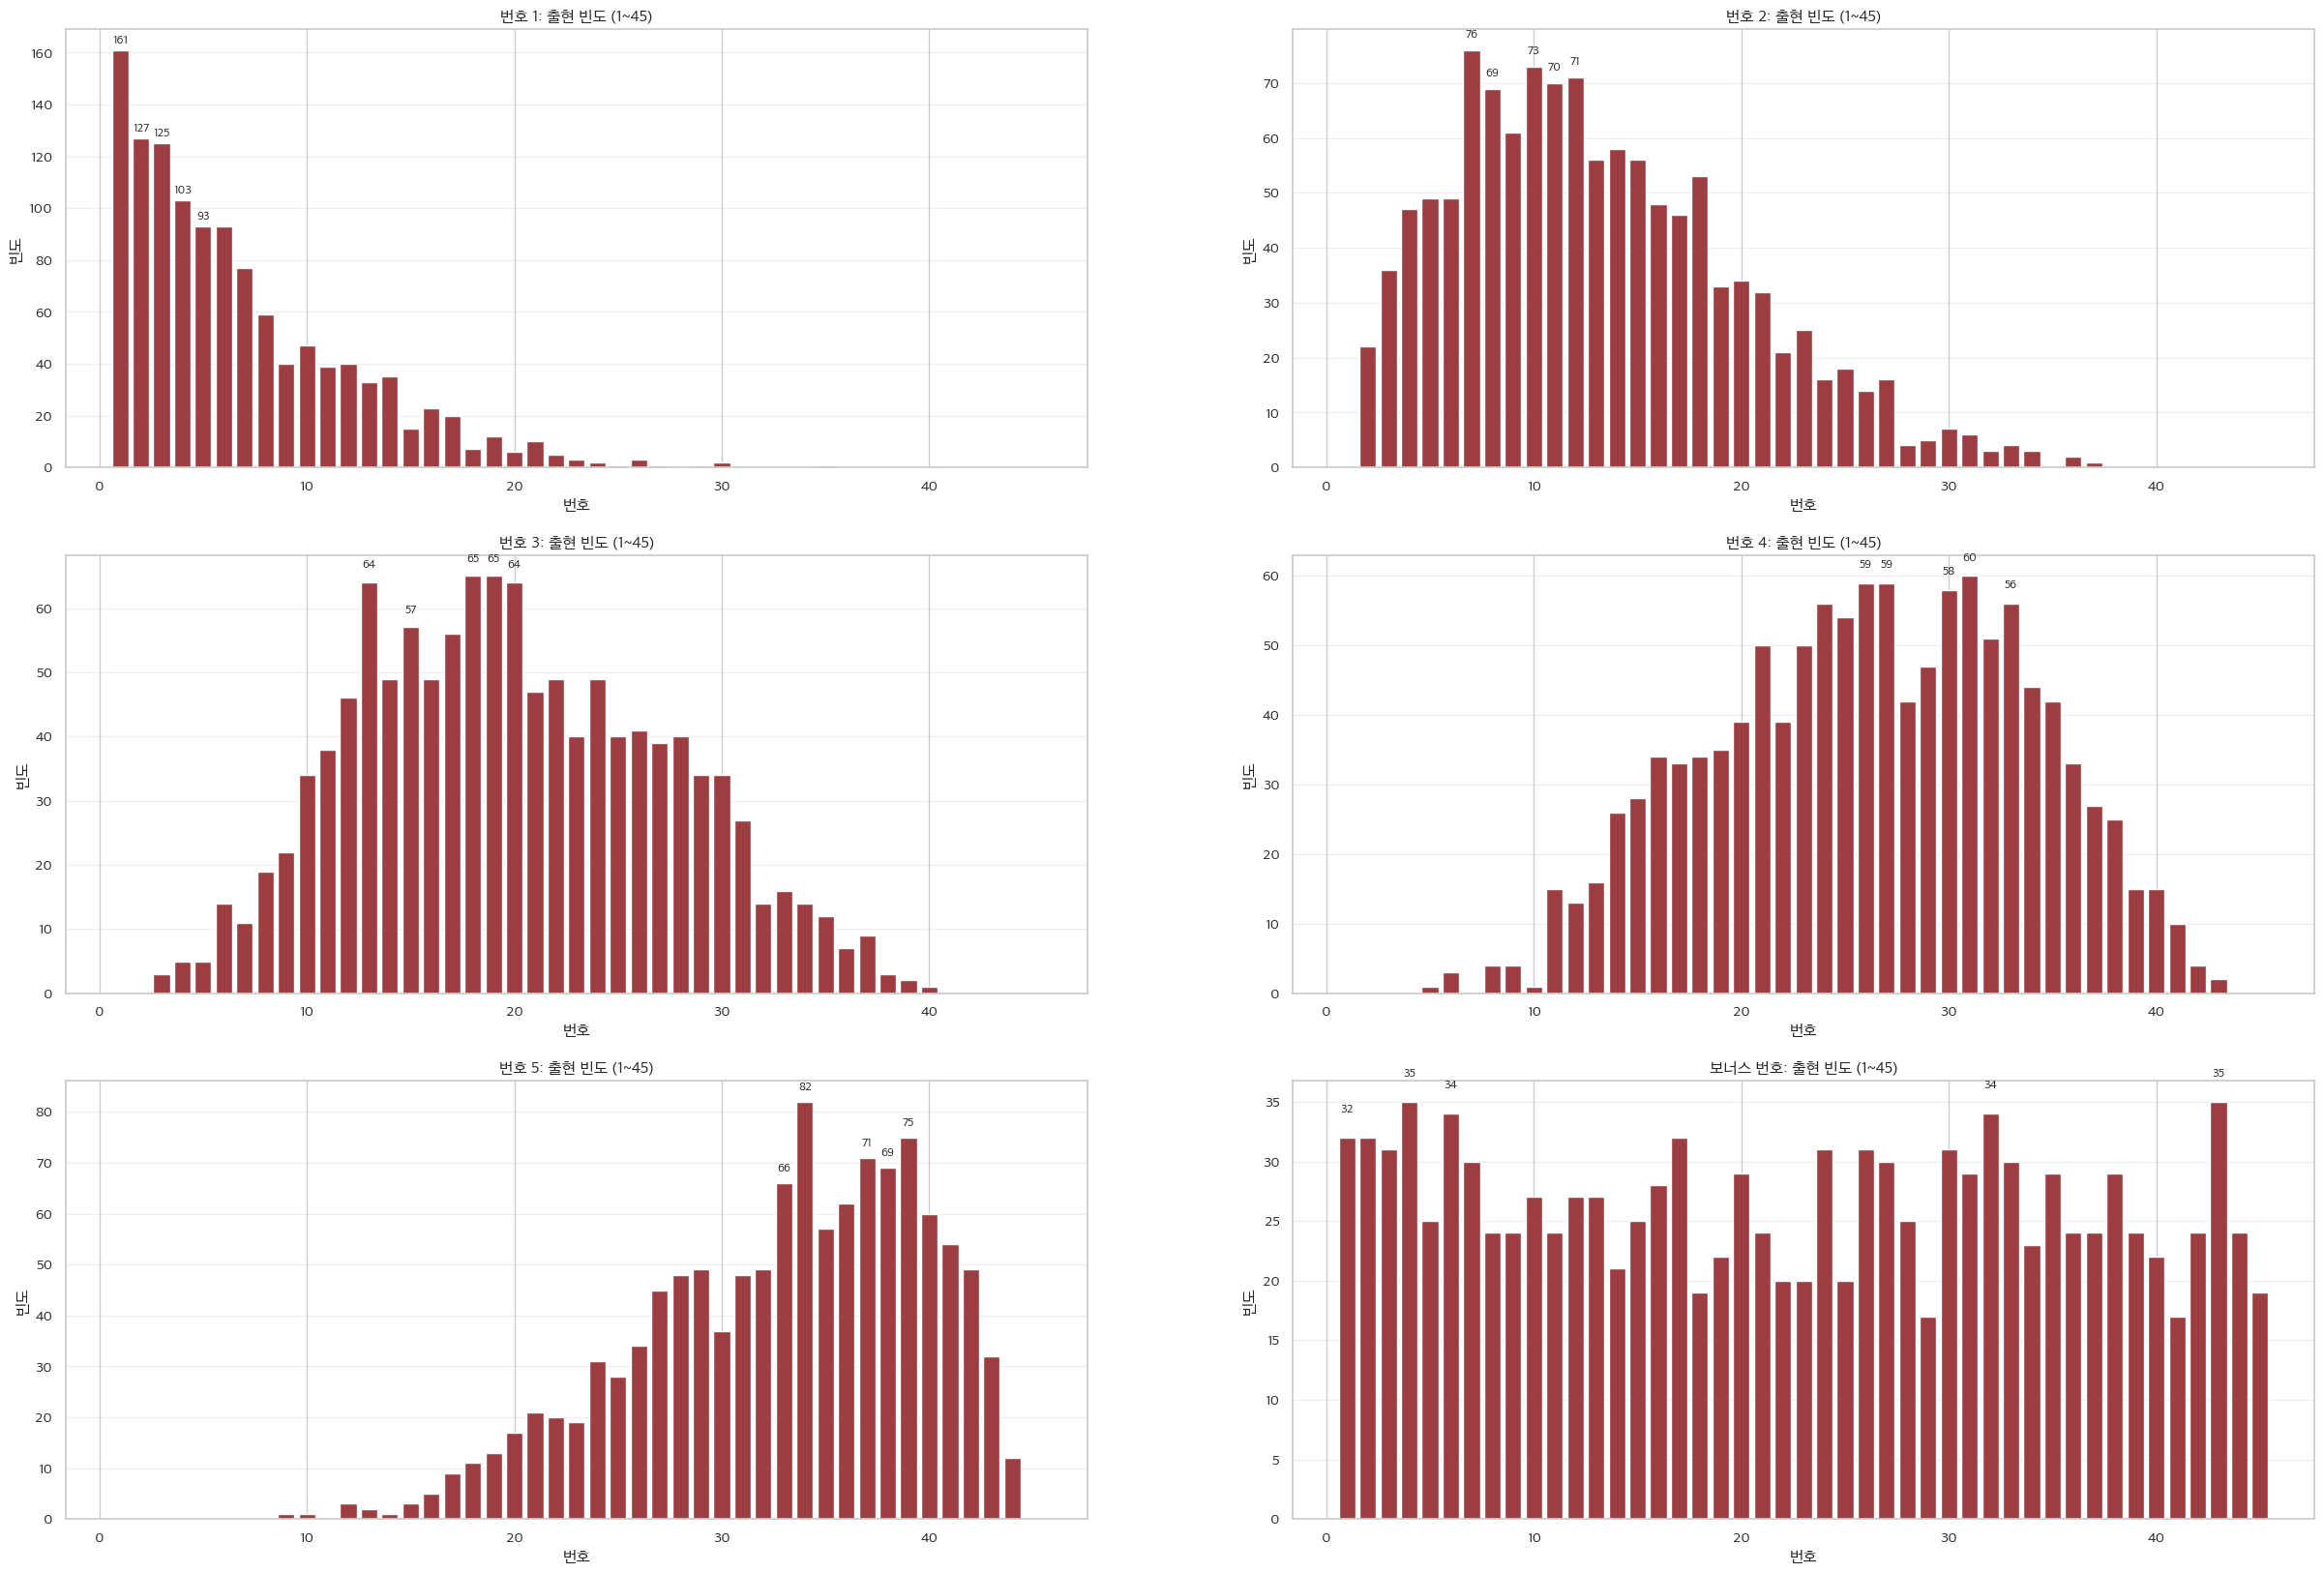

In [103]:
basic_number = list(range(1, 46))

fig, ax = plt.subplots(3, 2, figsize=(30, 20))

# 번호 1: 시각화 ------------------------------------
ax[0, 0].set_title('번호 1: 출현 빈도 (1~45)')
ax[0, 0].bar(basic_number, number_1_count, color="#9C3D41")
ax[0, 0].set_xlabel("번호")
ax[0, 0].set_ylabel("빈도")
ax[0, 0].grid(axis="y", alpha=0.3)

top5_idx = np.argsort(number_1_count)[-5:]
for i in top5_idx:
    ax[0, 0].text(
        basic_number[i],       
        number_1_count[i] + 2, 
        str(number_1_count[i]),
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

# 번호 2: 시각화 ------------------------------------
ax[0, 1].set_title('번호 2: 출현 빈도 (1~45)')
ax[0, 1].bar(basic_number, number_2_count, color="#9C3D41")
ax[0, 1].set_xlabel("번호")
ax[0, 1].set_ylabel("빈도")
ax[0, 1].grid(axis="y", alpha=0.3)

top5_idx = np.argsort(number_2_count)[-5:]
for i in top5_idx:
    ax[0, 1].text(
        basic_number[i],       
        number_2_count[i] + 2, 
        str(number_2_count[i]),
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
    
# 번호 3: 시각화 ------------------------------------
ax[1, 0].set_title('번호 3: 출현 빈도 (1~45)')
ax[1, 0].bar(basic_number, number_3_count, color="#9C3D41")
ax[1, 0].set_xlabel("번호")
ax[1, 0].set_ylabel("빈도")
ax[1, 0].grid(axis="y", alpha=0.3)

top5_idx = np.argsort(number_3_count)[-5:]
for i in top5_idx:
    ax[1, 0].text(
        basic_number[i],       
        number_3_count[i] + 2, 
        str(number_3_count[i]),
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

# 번호 4: 시각화 ------------------------------------
ax[1, 1].set_title('번호 4: 출현 빈도 (1~45)')
ax[1, 1].bar(basic_number, number_4_count, color="#9C3D41")
ax[1, 1].set_xlabel("번호")
ax[1, 1].set_ylabel("빈도")
ax[1, 1].grid(axis="y", alpha=0.3)

top5_idx = np.argsort(number_4_count)[-5:]
for i in top5_idx:
    ax[1, 1].text(
        basic_number[i],       
        number_4_count[i] + 2, 
        str(number_4_count[i]),
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

# 번호 5: 시각화 ------------------------------------
ax[2, 0].set_title('번호 5: 출현 빈도 (1~45)')
ax[2, 0].bar(basic_number, number_5_count, color="#9C3D41")
ax[2, 0].set_xlabel("번호")
ax[2, 0].set_ylabel("빈도")
ax[2, 0].grid(axis="y", alpha=0.3)

top5_idx = np.argsort(number_5_count)[-5:]
for i in top5_idx:
    ax[2, 0].text(
        basic_number[i],       
        number_5_count[i] + 2, 
        str(number_5_count[i]),
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

# 보너스 번호 : 시각화 ------------------------------------
ax[2, 1].set_title('보너스 번호: 출현 빈도 (1~45)')
ax[2, 1].bar(basic_number, number_bonus_count, color="#9C3D41")
ax[2, 1].set_xlabel("번호")
ax[2, 1].set_ylabel("빈도")
ax[2, 1].grid(axis="y", alpha=0.3)

top5_idx = np.argsort(number_bonus_count)[-5:]
for i in top5_idx:
    ax[2, 1].text(
        basic_number[i],       
        number_bonus_count[i] + 2, 
        str(number_bonus_count[i]),
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

plt.show()

### 색상별 출현 빈도

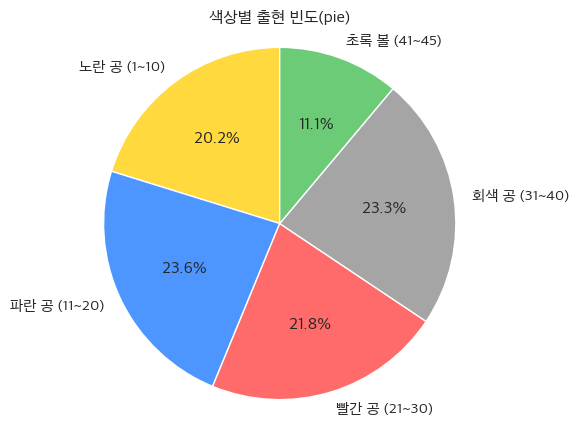

In [104]:
number = [0] * 5

yellow_ball = 0
blue_ball = 1
red_ball = 2
gray_ball = 3
green_ball = 4

for i in range(len(lotto_df)):
    for k in lotto_df.iloc[i]:
        if k > 40:
            number[green_ball] += 1
        elif k > 30:
            number[gray_ball] += 1
        elif k > 20:
            number[red_ball] += 1
        elif k > 10:
            number[blue_ball] += 1
        elif k > 1:
            number[yellow_ball] += 1
        

labels = ['노란 공 (1~10)', '파란 공 (11~20)', '빨간 공 (21~30)', '회색 공 (31~40)', '초록 볼 (41~45)']
colors = ['#FFD93D', '#4D96FF', '#FF6B6B', '#A5A5A5', '#6BCB77']

plt.figure(figsize=(5, 5))
plt.pie(
    number,
    labels=labels,
    colors=colors,
    autopct="%.1f%%",
    startangle=90,
    wedgeprops={"linewidth":1, "edgecolor":"white"},
)
plt.title("색상별 출현 빈도(pie)")
plt.axis("equal")
plt.show()

### 연도/월별 출현 빈도

In [105]:
lotto_df = original_df.drop(columns=[
    'Unnamed: 0',
    '1등_당첨자수', '1등_당첨금액',
    '2등_당첨자수', '2등_당첨금액', 
    '3등_당첨자수', '3등_당첨금액', 
    '4등_당첨자수', '4등_당첨금액', 
    '5등_당첨자수', '5등_당첨금액', 
], axis=1).reset_index(drop=True)

lotto_df['추첨일'] = pd.to_datetime(lotto_df['추첨일'], format='%Y%m%d')
lotto_df['월'] = lotto_df['추첨일'].dt.month
lotto_df['월']

lotto_df.head()

,년도,회차,추첨일,당첨번호_1,당첨번호_2,당첨번호_3,당첨번호_4,당첨번호_5,당첨번호_6,보너스번호,월
0,2025,1184,2025-08-09,14,16,23,25,31,37,42,8
1,2025,1183,2025-08-02,4,15,17,23,27,36,31,8
2,2025,1182,2025-07-26,1,13,21,25,28,31,22,7
3,2025,1181,2025-07-19,8,10,14,20,33,41,28,7
4,2025,1180,2025-07-12,6,12,18,37,40,41,3,7


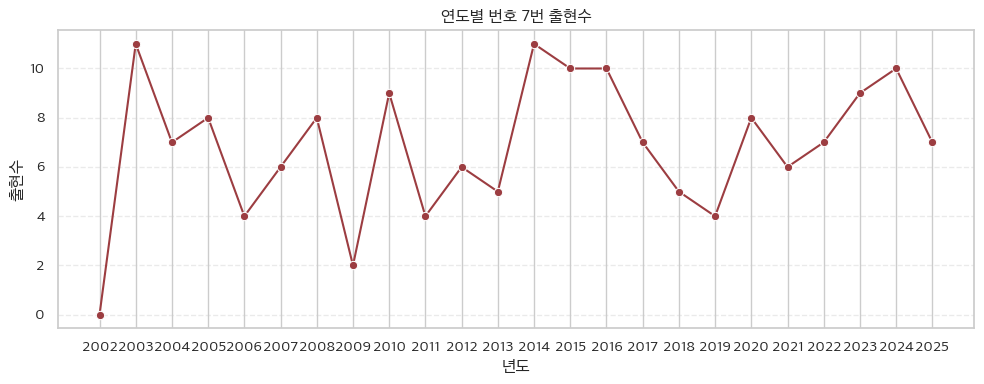

,년도,출현수
0,2002,0
1,2003,11
2,2004,7
3,2005,8
4,2006,4
5,2007,6
6,2008,8
7,2009,2
8,2010,9
9,2011,4


In [107]:
def plot_number_trend(lotto_df: pd.DataFrame, target_number: int, number_cols=None, year_col='년도', years=range(2002, 2026)):

    if number_cols is None:
        number_cols = lotto_df.columns[3:9]
    
    df = lotto_df[[year_col, *number_cols]].copy()

    long = df.melt(id_vars=year_col, value_vars=number_cols, value_name='번호')

    counts = (long[long['번호'].astype(int) == int(target_number)]
                .groupby(year_col).size()
                .reindex(years, fill_value=0)
                .reset_index(name='출현수'))
    counts.rename(columns={year_col: '년도'}, inplace=True)

    plt.figure(figsize=(10, 4))
    sns.lineplot(data=counts, x='년도', y='출현수', marker='o', color='#9C3D41')
    plt.title(f'연도별 번호 {int(target_number)}번 출현수')
    plt.xticks(list(years), rotation=0)
    plt.xlabel('년도')
    plt.ylabel('출현수')
    plt.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
    
    return counts

target_number = 7
plot_number_trend(lotto_df, target_number)

### 보너스 번호별 통계

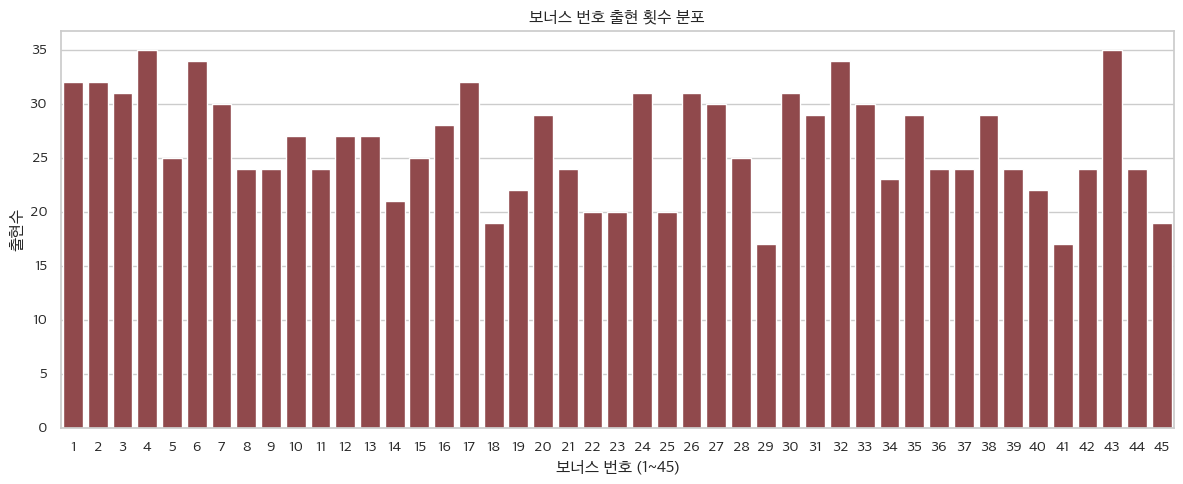

▶ 보너스 번호 기본 통계
count    1184.000000
mean       22.329392
std        13.156241
min         1.000000
25%        11.000000
50%        22.500000
75%        33.000000
max        45.000000

▶ 가장 많이 나온 보너스 번호 Top 5
 번호  출현수
  4   35
 43   35
  6   34
 32   34
  1   32


In [108]:
def bonus_number_analysis(lotto_df: pd.DataFrame, bonus_col=None):
    if bonus_col is None:
        bonus_col = lotto_df.columns[9]
    
    bonus_series = lotto_df[bonus_col].astype(int)

    bonus_counts = bonus_series.value_counts().sort_index()
    bonus_df = bonus_counts.reset_index()
    bonus_df.columns = ["번호", "출현수"]

    plt.figure(figsize=(12, 5))
    sns.barplot(data=bonus_df, x="번호", y="출현수", color="#9C3D41")
    plt.title("보너스 번호 출현 횟수 분포")
    plt.xlabel("보너스 번호 (1~45)")
    plt.ylabel("출현수")
    plt.tight_layout()
    plt.show()


    desc = bonus_series.describe()
    most_common = bonus_df.sort_values("출현수", ascending=False).head(5)

    print("▶ 보너스 번호 기본 통계")
    print(desc.to_string())
    print("\n▶ 가장 많이 나온 보너스 번호 Top 5")
    print(most_common.to_string(index=False))

    return {
        "bonus_counts": bonus_df,
        "desc": desc,          
        "most_common": most_common
    }

result = bonus_number_analysis(lotto_df)

### 홀/짝 분포

/var/folders/l_/jwxy6nr92x313h1886h_krpm0000gn/T/ipykernel_56094/3572580838.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x='홀짝', y='출현수', palette=['#9C3D41', '#3D7B9C'])


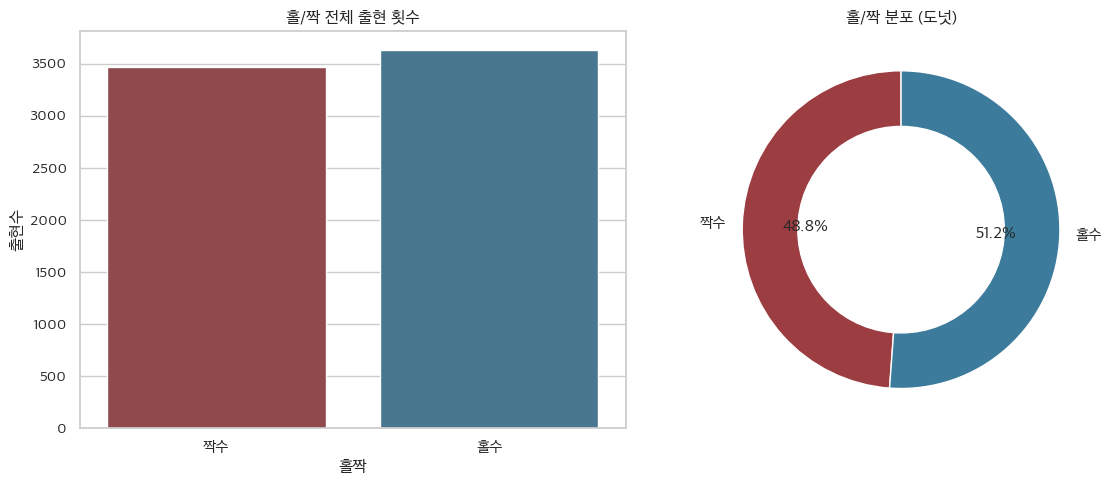

In [109]:
def plot_odd_even_counts(lotto_df: pd.DataFrame, number_cols=None):
    if number_cols is None:
        number_cols = lotto_df.columns[3:9]
    
    df = lotto_df[number_cols].copy()

    long = df.melt(value_vars=number_cols, value_name='번호')

    long['홀짝'] = long['번호'].astype(int) % 2
    long['홀짝'] = long['홀짝'].map({1: '홀수', 0: '짝수'})

    counts = long.groupby('홀짝').size().reset_index(name='출현수')

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.barplot(data=counts, x='홀짝', y='출현수', palette=['#9C3D41', '#3D7B9C'])
    plt.title('홀/짝 전체 출현 횟수')

    plt.subplot(1, 2, 2)
    wedges, texts, autotexts = plt.pie(
        counts['출현수'],
        labels=counts['홀짝'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#9C3D41', '#3D7B9C']
    )
    centre_circle = plt.Circle((0, 0), 0.65, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    plt.title('홀/짝 분포 (도넛)')

    plt.tight_layout()
    plt.show()

    return counts

counts = plot_odd_even_counts(lotto_df)

### 번호합 분포

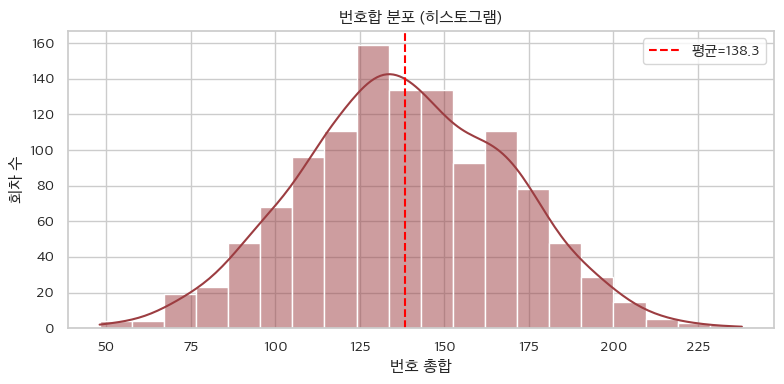

▶ 번호합 통계 요약
count    1184.000000
mean      138.283784
std        30.803451
min        48.000000
25%       117.000000
50%       137.500000
75%       161.000000
max       238.000000

▶ 이상치 구간: < 51.0 또는 > 227.0
이상치 개수: 4 회차


In [110]:
def number_sum_analysis(lotto_df: pd.DataFrame, number_cols=None):
    if number_cols is None:
        number_cols = lotto_df.columns[3:9]

    lotto_df['번호합'] = lotto_df[number_cols].astype(int).sum(axis=1)

    desc = lotto_df['번호합'].describe()

    plt.figure(figsize=(8, 4))
    sns.histplot(lotto_df['번호합'], bins=20, kde=True, color='#9C3D41')
    plt.axvline(desc['mean'], color='red', linestyle='--', label=f"평균={desc['mean']:.1f}")
    plt.title('번호합 분포 (히스토그램)')
    plt.xlabel('번호 총합')
    plt.ylabel('회차 수')
    plt.legend()
    plt.tight_layout()
    plt.show()

    Q1 = desc['25%']
    Q3 = desc['75%']
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = lotto_df[(lotto_df['번호합'] < lower) | (lotto_df['번호합'] > upper)]

    print("▶ 번호합 통계 요약")
    print(desc.to_string())
    print("\n▶ 이상치 구간: < {:.1f} 또는 > {:.1f}".format(lower, upper))
    print(f"이상치 개수: {len(outliers)} 회차")

    return {
        'desc': desc,
        'outliers': outliers,
        'lower': lower, 'upper': upper
    }

result = number_sum_analysis(lotto_df)

### 번호 페어 분석

▶ 자주 나온 번호쌍 (Top 20):
    번호1  번호2  출현수
0    11   21   34
1    33   40   32
2    12   24   30
3     6   38   30
4    34   42   29
5    10   31   29
6     3   20   29
7     1   28   28
8     3   13   28
9    19   21   28
10   30   34   28
11   15   34   28
12   14   15   28
13    8   27   27
14   12   34   27
15    7   18   27
16   18   31   27
17   13   33   27
18    8   39   27
19   31   34   27


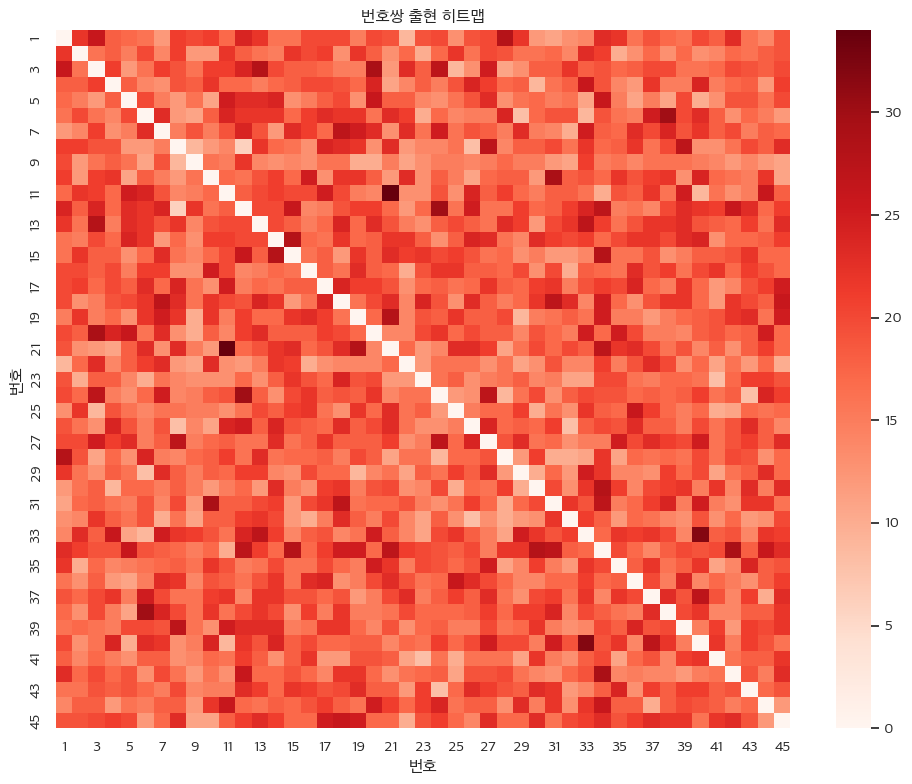

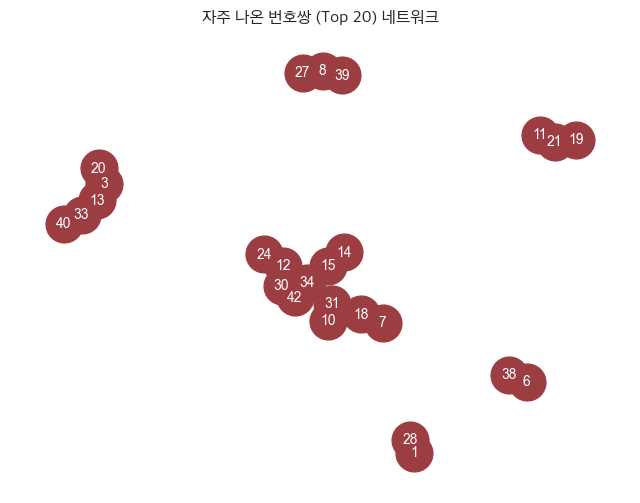

In [111]:
import itertools
import networkx as nx

def number_pair_analysis(lotto_df: pd.DataFrame, number_cols=None, top_n=20):
    if number_cols is None:
        number_cols = lotto_df.columns[3:9]
    
    df = lotto_df[number_cols].astype(int)

    pair_counts = {}
    for _, row in df.iterrows():
        numbers = row.tolist()
        for a, b in itertools.combinations(sorted(numbers), 2):
            pair_counts[(a, b)] = pair_counts.get((a, b), 0) + 1
    
    pair_df = (
        pd.DataFrame([(*k, v) for k, v in pair_counts.items()],
                     columns=['번호1', '번호2', '출현수'])
        .sort_values('출현수', ascending=False)
        .reset_index(drop=True)
    )

    top_pairs = pair_df.head(top_n)
    print("▶ 자주 나온 번호쌍 (Top {}):".format(top_n))
    print(top_pairs)

    matrix = pd.DataFrame(0, index=range(1, 46), columns=range(1, 46))
    for (a, b), v in pair_counts.items():
        matrix.loc[a, b] = v
        matrix.loc[b, a] = v

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, cmap="Reds", cbar=True)
    plt.title("번호쌍 출현 히트맵")
    plt.xlabel("번호")
    plt.ylabel("번호")
    plt.tight_layout()
    plt.show()

    G = nx.Graph()
    for _, row in top_pairs.iterrows():
        G.add_edge(row['번호1'], row['번호2'], weight=row['출현수'])

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, k=0.5, seed=42)
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color="#9C3D41")
    nx.draw_networkx_labels(G, pos, font_size=10, font_color="white")
    edges = nx.draw_networkx_edges(
        G, pos, width=[d['weight']*0.2 for (_,_,d) in G.edges(data=True)],
        edge_color="#9C3D41"
    )
    plt.title(f"자주 나온 번호쌍 (Top {top_n}) 네트워크")
    plt.axis("off")
    plt.show()

    recommendation = set(top_pairs[['번호1','번호2']].values.flatten())

    return {
        'pair_df': pair_df,
        'top_pairs': top_pairs,
        'recommendation': recommendation
    }

result = number_pair_analysis(lotto_df, top_n=20)

### 번호 간 간격 분석

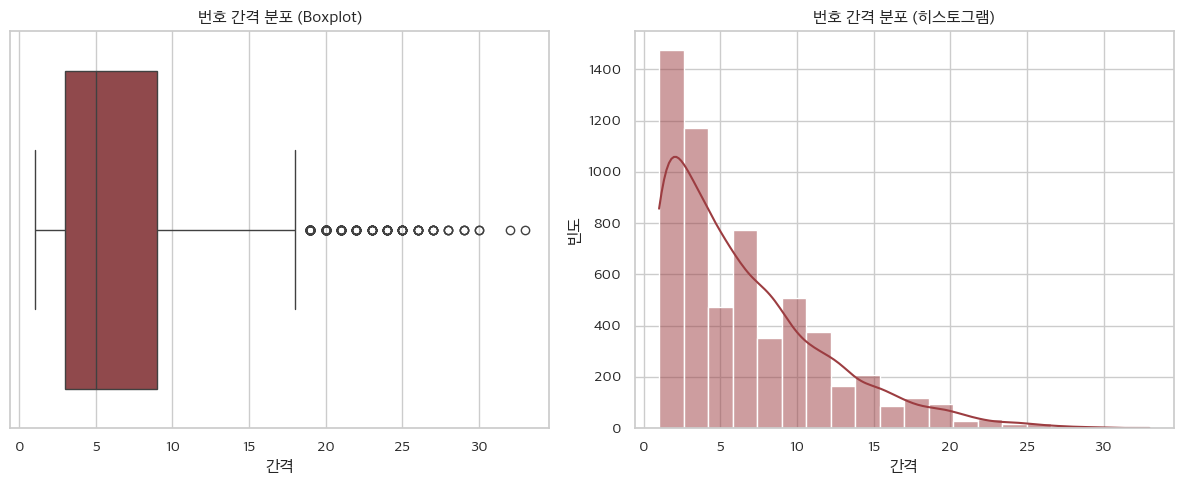

▶ 번호 간격 기본 통계
count    5920.000000
mean        6.543581
std         5.167457
min         1.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        33.000000

▶ 자주 나온 간격 Top 10
   간격   빈도
0   1  787
1   2  688
2   3  623
3   4  548
4   5  472
5   6  425
6   8  353
7   7  350
8   9  291
9  10  217


In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def number_gap_analysis(lotto_df: pd.DataFrame, number_cols=None):
    if number_cols is None:
        number_cols = lotto_df.columns[3:9]
    
    df = lotto_df[number_cols].astype(int)

    gaps = []
    for _, row in df.iterrows():
        nums = sorted(row.tolist())
        diffs = [nums[i+1] - nums[i] for i in range(len(nums)-1)]
        gaps.extend(diffs)

    gap_series = pd.Series(gaps, name="번호간격")

    desc = gap_series.describe()

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.boxplot(x=gap_series, color="#9C3D41")
    plt.title("번호 간격 분포 (Boxplot)")
    plt.xlabel("간격")

    plt.subplot(1, 2, 2)
    sns.histplot(gap_series, bins=20, kde=True, color="#9C3D41")
    plt.title("번호 간격 분포 (히스토그램)")
    plt.xlabel("간격")
    plt.ylabel("빈도")

    plt.tight_layout()
    plt.show()

    top_gaps = gap_series.value_counts().head(10).reset_index()
    top_gaps.columns = ["간격", "빈도"]

    print("▶ 번호 간격 기본 통계")
    print(desc.to_string())
    print("\n▶ 자주 나온 간격 Top 10")
    print(top_gaps)

    return {
        "desc": desc,     
        "gaps": gap_series,
        "top_gaps": top_gaps 
    }

result = number_gap_analysis(lotto_df)